✅ Dataset generated: 5000 rows × 15 cols
   EnergyConsumption range: 8.5 – 300.1 kWh

Train: 4000 samples | Test: 1000 samples

========== Random Forest Results ==========
  R² Score       : 0.9401  (94.01%)
  CV R² (5-fold) : 0.9358  (93.58%)
  RMSE           : 13.4232
  MAE            : 10.3503

Feature Importances:
Occupancy          0.677135
SquareFootage      0.099268
Temperature        0.070801
RenewableEnergy    0.024408
Insulation         0.023820
Humidity           0.023267
NumAppliances      0.018350
Hour               0.016422
Month              0.013281
HVACUsage          0.012399
DayOfWeek          0.010586
SolarPanels        0.004422
LightingUsage      0.003566
Holiday            0.002274


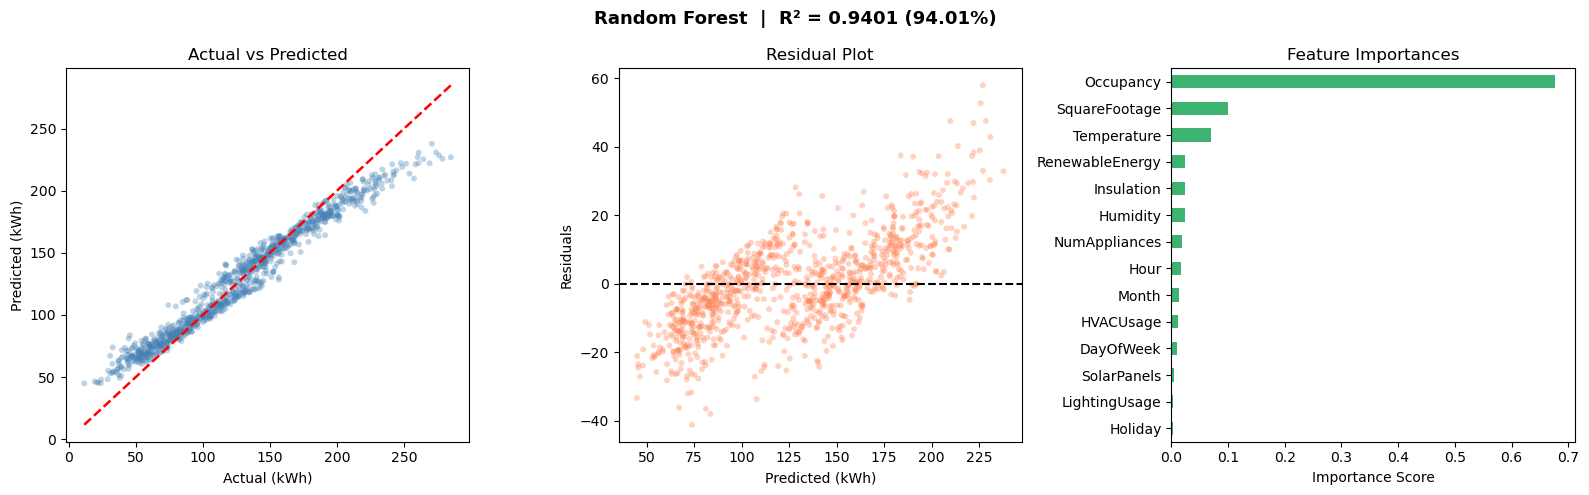


📊 Plot saved as 'random_forest_results.png'


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
n = 5000

temperature      = np.random.uniform(15, 45, n)      
humidity         = np.random.uniform(20, 90, n)      
square_footage   = np.random.uniform(500, 5000, n)   
occupancy        = np.random.randint(0, 50, n)       
hvac_usage       = np.random.choice([0, 1], n, p=[0.4, 0.6])
lighting_usage   = np.random.choice([0, 1], n, p=[0.3, 0.7])
renewable_energy = np.random.uniform(0, 1, n)       
hour             = np.random.randint(0, 24, n)
day_of_week      = np.random.randint(0, 7, n)
month            = np.random.randint(1, 13, n)
holiday          = np.random.choice([0, 1], n, p=[0.85, 0.15])
num_appliances   = np.random.randint(1, 20, n)
insulation       = np.random.uniform(0, 1, n)        
solar_panels     = np.random.choice([0, 1], n, p=[0.6, 0.4])


energy_consumption = (
    0.40  * temperature                        +
    0.10  * humidity                           +
    0.005 * square_footage                     +
    1.20  * occupancy                          +
    15.0  * hvac_usage                         +
    5.0   * lighting_usage                     +
   -10.0  * renewable_energy                   +
    0.80  * num_appliances                     +
   -8.0   * insulation                         +
   -6.0   * solar_panels                       +
    3.0   * (hour / 24)                        +
    1.5   * (month / 12)                       +
   -2.0   * holiday                            +
    0.05  * temperature * occupancy            +   
    0.03  * square_footage * occupancy / 100   +  
    np.random.normal(0, 2.5, n)                    
)

df = pd.DataFrame({
    'Temperature':      temperature,
    'Humidity':         humidity,
    'SquareFootage':    square_footage,
    'Occupancy':        occupancy,
    'HVACUsage':        hvac_usage,
    'LightingUsage':    lighting_usage,
    'RenewableEnergy':  renewable_energy,
    'Hour':             hour,
    'DayOfWeek':        day_of_week,
    'Month':            month,
    'Holiday':          holiday,
    'NumAppliances':    num_appliances,
    'Insulation':       insulation,
    'SolarPanels':      solar_panels,
    'EnergyConsumption': energy_consumption
})


df.to_csv("energy_consumption_synthetic.csv", index=False)
print(f"✅ Dataset generated: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"   EnergyConsumption range: {df['EnergyConsumption'].min():.1f} – "
      f"{df['EnergyConsumption'].max():.1f} kWh")


FEATURES = [c for c in df.columns if c != 'EnergyConsumption']
TARGET   = 'EnergyConsumption'

X = df[FEATURES]
y = df[TARGET]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")


rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
cv   = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2').mean()

print("\n========== Random Forest Results ==========")
print(f"  R² Score       : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  CV R² (5-fold) : {cv:.4f}  ({cv*100:.2f}%)")
print(f"  RMSE           : {rmse:.4f}")
print(f"  MAE            : {mae:.4f}")
print("===========================================")


fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nFeature Importances:")
print(fi.to_string())


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Random Forest  |  R² = {r2:.4f} ({r2*100:.2f}%)",
             fontsize=13, fontweight="bold")


axes[0].scatter(y_test, y_pred, alpha=0.35, s=18, color="steelblue", edgecolors="none")
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, "r--", lw=1.8)
axes[0].set_xlabel("Actual (kWh)")
axes[0].set_ylabel("Predicted (kWh)")
axes[0].set_title("Actual vs Predicted")


residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.35, s=18, color="coral", edgecolors="none")
axes[1].axhline(0, color="black", lw=1.5, linestyle="--")
axes[1].set_xlabel("Predicted (kWh)")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")


fi.plot(kind='barh', ax=axes[2], color='mediumseagreen')
axes[2].invert_yaxis()
axes[2].set_xlabel("Importance Score")
axes[2].set_title("Feature Importances")

plt.tight_layout()
plt.savefig("random_forest_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📊 Plot saved as 'random_forest_results.png'")
